# Multi-Layer Feature Extraction


> **Note:** This is *not* an implementation of PatchCore (Roth et al., CVPR 2022 —
> arXiv:2106.08265). PatchCore keeps the spatial patch grid from intermediate feature
> maps and builds a memory bank of local patch descriptors for pixel-level localisation.
> This notebook instead **globally average-pools** each layer into a single vector per
> image.

### What is different from previous work

This notebook goes back to the raw images and extracts features from **two intermediate
layers** of a pretrained CNN (WideResNet50) combining
multiple layers: earlier layers keep fine local detail (edges, texture, unusual
structure); later layers keep higher-level semantics. Combining both gives a richer,
multi-scale representation but each layer is still collapsed to one vector per image,
so this remains an **image-level** method, not a patch-level one.

### Pipeline overview

```
Raw .png images
      ↓
WideResNet50 pretrained on ImageNet  (FROZEN — no training)
      ├─ Layer 2 → (512-dim) local structure
      └─ Layer 3 → (1024-dim) semantic content
      ↓
Global average pool each layer → L2-normalise → concatenate → 1536-dim per image
      ↓
Whiten (StandardScaler)
      ↓
Memory bank (all feature vectors stored)
      ↓
k-NN anomaly score: distance to k nearest neighbours   (DN2-style)
      ↓
Evaluate: ROC-AUC, PR-AUC, Recall@100, Spearman
      ↓
Compare against Protege baseline
```


## 1. Helper Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    pairwise_distances_chunked
)


BASE_DIR = Path.cwd().parent

# Data loading

def load_features():
    path = BASE_DIR / "data" / "mgcls_byol_features.parquet"
    df = pd.read_parquet(path)
    print(f"Features loaded: {df.shape}")
    return df


def load_catalogue():
    path = BASE_DIR / "data" / "protege_catalogue.csv"
    df = pd.read_csv(path)
    print(f"Catalogue loaded: {df.shape}")
    return df

# Metrics

def compute_metrics(y_true, scores):
    """Return ROC-AUC and PR-AUC."""
    return {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
    }


def topk_recall(y_true, scores, k=100):
    """Fraction of true positives recovered in the top-k ranked items."""
    if isinstance(scores, pd.Series):
        ranked = scores.sort_values(ascending=False).index[:k]
    else:
        ranked = pd.Series(scores).sort_values(ascending=False).index[:k]

    return y_true.loc[ranked].sum() / y_true.sum()

# Score utilities

def rank_normalise(scores):
    ranks = scores.rank(method='average', ascending=True)
    return (ranks - 1) / (len(ranks) - 1)


def score_ensemble(score_dict, weights=None):
    normalised = [rank_normalise(s) for s in score_dict.values()]

    if weights is None:
        weights = [1.0 / len(normalised)] * len(normalised)

    combined = sum(w * s for w, s in zip(weights, normalised))
    return combined.rename("ensemble")

# Device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

Device : cpu
PyTorch: 2.7.1+cu126


In [2]:
def compute_ind_sum(found_inds, all_inds):
    this_found_inds = sorted(found_inds)
    out = np.zeros(len(all_inds))
    for i in this_found_inds:
        out[i:] += 1
    return out


def cumulative_sum(anomaly_scores, labels):
    """Running count of true anomalies as we walk down the ranked list."""
    sorted_inds = anomaly_scores.sort_values(ascending=False).index
    labs        = labels.loc[anomaly_scores.index]
    anom_inds   = labs[labs == 1].index
    found_inds  = []
    for i in anom_inds:
        pos = np.where(sorted_inds == i)[0]
        if len(pos) > 0:
            found_inds.append(pos[0])
    return compute_ind_sum(found_inds, sorted_inds)


def topk_recall(y_true, scores, k=100):
    """Fraction of true anomalies found in the top-k ranked candidates."""
    ranked = scores.sort_values(ascending=False).index[:k]
    return y_true.loc[ranked].sum() / y_true.sum()


def evaluate(name, scores, y_true, labels_raw):
    """Return one result row in the standard format."""
    m = compute_metrics(y_true, scores)
    return {
        'Method':           name,
        'ROC-AUC (4-5)':    round(m['roc_auc'], 4),
        'PR-AUC (4-5)':     round(m['pr_auc'],  4),
        'Recall@100 (4-5)': round(topk_recall(y_true, scores), 4),
        'Spearman (1-5)':   round(labels_raw.corr(scores, method='spearman'), 4),
    }


def show_results(methods_dict, y_true, labels_raw):
    """Standard evaluation table sorted by ROC-AUC."""
    rows = [evaluate(n, s, y_true, labels_raw)
            for n, s in methods_dict.items()]
    df = pd.DataFrame(rows).set_index('Method')
    display(df.sort_values('ROC-AUC (4-5)', ascending=False))
    return df


def discovery_plot(methods_dict, y_true, highlight=None):
    """Standard cumulative discovery curve."""
    colors     = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#8c564b',
                  '#e377c2','#17becf','#9467bd','#bcbd22','#e74c3c']
    linestyles = ['-','--','-.', ':','-','-.','--',':','-.','--']

    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, scores), c, ls in zip(methods_dict.items(), colors, linestyles):
        lw  = 2.4 if (highlight and name in highlight) else 1.3
        cum = cumulative_sum(scores, y_true)
        ax.plot(cum, label=name, color=c, linestyle=ls, linewidth=lw)
    ax.set_xlabel('Index in list ordered by algorithm score')
    ax.set_ylabel('Number of anomalies found')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 2. Load Catalogue and Baseline

In [3]:
# Load catalogue and BYOL features (needed for objid alignment and baseline)
X_byol = load_features()
cat    = load_catalogue()

# Restrict to objects that were actually human-scored in the evaluation
# subset. evaluation_subset_author_ML_score == -1 means "never scored" --
# these are NOT confirmed negatives and must be excluded, not folded into
# the negative class.
cat_eval = cat[cat['evaluation_subset_author_ML_score'] != -1].copy()

# Intersect with the feature index (safer than assuming full coverage)
eval_ids = cat_eval['objid'][cat_eval['objid'].isin(X_byol.index)]
X_byol   = X_byol.loc[eval_ids]

cat_eval = cat_eval.set_index('objid').loc[eval_ids]

labels        = cat_eval['evaluation_subset_author_ML_score']
y_interesting = (labels >= 4).astype(int)

# Protege baseline score -- our gold standard comparison
protege_scores = cat_eval['protege_score']
protege_scores.name = 'score'

print(f'Dataset  : {X_byol.shape[0]} objects')
print(f'Anomalies: {y_interesting.sum()} / {len(y_interesting)} (score \u2265 4)')
print(f'Prevalence: {y_interesting.mean():.2%}')


Features loaded: (6332, 1280)
Catalogue loaded: (6161, 12)
Dataset  : 1031 objects
Anomalies: 86 / 1031 (score ≥ 4)
Prevalence: 8.34%


In [4]:
# Sanity check: should now show only the 5 real score classes (1-5), no -1
print(labels.value_counts().sort_index())


evaluation_subset_author_ML_score
1    384
2    439
3    122
4     62
5     24
Name: count, dtype: int64


## 3. Discover Images

Images are stored in two folders under `data/images/`.
We build an `objid → file path` mapping, then check alignment with the catalogue.


In [6]:
IMAGE_DIRS = [
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part1',
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part2',
]

# ── Key fact (from the README) ────────────────────────────────────────────────
# The .png filenames are the PROTEGE RANK of each object.
# 0.png = the object Protege ranked #0 (highest anomaly score)
# 1.png = rank #1, and so on.
# The catalogue has a 'protege_rank' column that holds these integers.

# Build integer protege_rank → Path mapping
image_map_int = {}
for d in IMAGE_DIRS:
    if not d.exists():
        print(f'WARNING: {d} not found')
        continue
    for p in d.glob('*.png'):
        image_map_int[int(p.stem)] = p

print(f'Total images found       : {len(image_map_int)}')
print(f'Protege rank range       : {min(image_map_int)} – {max(image_map_int)}')

# Build objid → Path using protege_rank column
image_map = {}
for _, row in cat.iterrows():
    rank  = int(row['protege_rank'])
    objid = row['objid']
    if rank in image_map_int:
        image_map[objid] = image_map_int[rank]

print(f'Mapped objids → images   : {len(image_map)}')

# Align with X_byol index
objids_all     = list(X_byol.index)
objids_found   = [oid for oid in objids_all if oid in image_map]
objids_missing = [oid for oid in objids_all if oid not in image_map]

print(f'Objects in catalogue     : {len(objids_all)}')
print(f'Objects with images      : {len(objids_found)}')
print(f'Objects missing images   : {len(objids_missing)}')

if objids_missing:
    print(f'  First 3 missing objids : {objids_missing[:3]}')


Total images found       : 6161
Protege rank range       : 0 – 6160
Mapped objids → images   : 6161
Objects in catalogue     : 1031
Objects with images      : 1031
Objects missing images   : 0


### Preview Sample Images

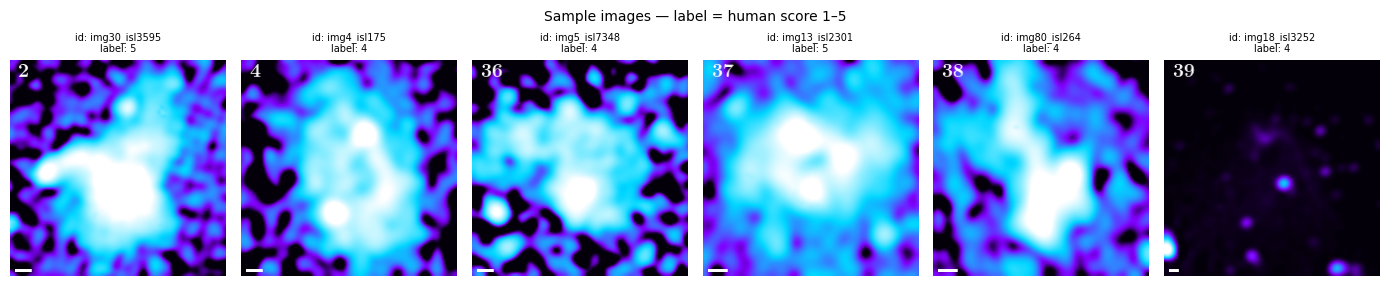

In [7]:
sample_ids = objids_found[:6]

fig, axes = plt.subplots(1, len(sample_ids), figsize=(14, 3))
for ax, oid in zip(axes, sample_ids):
    img = Image.open(image_map[oid]).convert('RGB')
    lbl = labels.loc[oid] if oid in labels.index else '?'
    ax.imshow(img)
    ax.set_title(f'id: {oid}\nlabel: {lbl}', fontsize=7)
    ax.axis('off')
plt.suptitle('Sample images — label = human score 1–5', fontsize=10)
plt.tight_layout()
plt.show()


## 4. Multi-Layer Feature Extractor

We use **WideResNet50_2** pretrained on ImageNet as a frozen feature extractor,
following the DN2 / SPADE approach of reusing an ImageNet-pretrained backbone
without any fine-tuning.

### Why WideResNet50?
- Common backbone choice in deep nearest-neighbor anomaly detection work (DN2, SPADE, PatchCore all use ResNet-family backbones)
- Pretrained on ImageNet — strong general visual features
- Wide architecture (2× channels) captures more detail than standard ResNet50

### Why these two layers?

| Layer | Output channels | What it captures |
|---|---|---|
| `layer2` | 512 | Local texture, edges, spatial patterns, unusual morphology |
| `layer3` | 1024 | Higher-level semantic content, global structure |

Here, each layer's spatial feature map is collapsed to **one vector per image** using
**global average pooling**, then **L2-normalised** independently. Final concatenated vector: 512 + 1024 =
**1536 dimensions per image**.

The network weights are **never updated** we only do a forward pass.


In [8]:
class MultiLayerExtractor:
    """
    Extracts 1536-dim multi-layer features from images using frozen WideResNet50.

    Architecture:
        image (3×224×224)
            ↓  WideResNet50 (frozen)
            ├─ layer2 → pool → L2-norm → 512-dim
            └─ layer3 → pool → L2-norm → 1024-dim
            ↓  concatenate
        feature vector (1536-dim)

    No training — only inference (one forward pass per image).
    """

    def __init__(self, device):
        self.device = device

        # Load WideResNet50 pretrained on ImageNet
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1
        )
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False     # freeze all weights

        # Sub-network up to layer2 (local features, 512 channels)
        self.layer2_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2
        ).to(device)

        # Sub-network up to layer3 (semantic features, 1024 channels)
        self.layer3_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3
        ).to(device)

        # Global average pool: (C, H, W) → (C,)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # ImageNet normalisation — required for pretrained weights
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            # Radio images are single-channel — replicate to 3 channels
            T.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])

    def extract_batch(self, image_paths: list) -> np.ndarray:
        """
        Extract 1536-dim features for a list of image file paths.
        Returns np.ndarray of shape (N, 1536).
        """
        tensors = []
        for p in image_paths:
            try:
                img = Image.open(p).convert('RGB')
                tensors.append(self.transform(img))
            except Exception as e:
                print(f'  WARNING: could not load {p}: {e}')
                tensors.append(torch.zeros(3, 224, 224))

        batch = torch.stack(tensors).to(self.device)

        with torch.no_grad():
            # (N, 512, H2, W2) → pool → (N, 512)
            f2 = self.pool(self.layer2_net(batch)).squeeze(-1).squeeze(-1)
            # (N, 1024, H3, W3) → pool → (N, 1024)
            f3 = self.pool(self.layer3_net(batch)).squeeze(-1).squeeze(-1)

        f2 = f2.cpu().numpy()
        f3 = f3.cpu().numpy()

        # L2-normalise each layer independently
        f2_norm = normalize(f2, norm='l2')   # (N, 512)
        f3_norm = normalize(f3, norm='l2')   # (N, 1024)

        return np.concatenate([f2_norm, f3_norm], axis=1)   # (N, 1536)


extractor = MultiLayerExtractor(device)
print('Extractor ready.')
print('Output: 512 (layer2) + 1024 (layer3) = 1536 dims per image')


Extractor ready.
Output: 512 (layer2) + 1024 (layer3) = 1536 dims per image


## 7. Extract Features for All Images

Process every image in batches and save to disk.
The result is a parquet file saved to `data/patchcore_features_v3.parquet`.

**Caching:** if the file already exists, it is loaded directly —
you never need to re-run the extraction.


In [9]:
BATCH_SIZE   = 32
SAVE_PATH    = BASE_DIR / 'data' / 'patchcore_features_multi.parquet'

# ── Delete corrupted cache if it exists but is invalid ────────────────────────
if SAVE_PATH.exists():
    try:
        df_pc_features = pd.read_parquet(SAVE_PATH)
        print(f'Loaded: {df_pc_features.shape}  (objects × feature dims)')
    except Exception as e:
        print(f'Corrupted cache detected ({e}), deleting and re-extracting...')
        SAVE_PATH.unlink()

# ── Extract if no valid cache ──────────────────────────────────────────────────
if not SAVE_PATH.exists():
    print(f'Extracting features for {len(objids_found)} images...')
    print(f'Batch size : {BATCH_SIZE}')
    print(f'Save path  : {SAVE_PATH}')
    print()

    all_feats  = []
    all_objids = []

    for start in range(0, len(objids_found), BATCH_SIZE):
        batch_ids   = objids_found[start : start + BATCH_SIZE]
        batch_paths = [image_map[oid] for oid in batch_ids]
        feats = extractor.extract_batch(batch_paths)   # (B, 1536)
        all_feats.append(feats)
        all_objids.extend(batch_ids)

        n_done = min(start + BATCH_SIZE, len(objids_found))
        print(f'  {n_done:4d} / {len(objids_found)} images processed', end='\r')

    print()
    arr = np.vstack(all_feats)
    df_pc_features = pd.DataFrame(arr, index=all_objids)
    df_pc_features.index.name = 'objid'
    df_pc_features.to_parquet(SAVE_PATH)
    print(f'\nSaved to {SAVE_PATH}')
    print(f'Feature matrix: {df_pc_features.shape}')

Extracting features for 1031 images...
Batch size : 32
Save path  : /idia/users/mrandrianasy/PatchCore/data/patchcore_features_multi.parquet

  1031 / 1031 images processed

Saved to /idia/users/mrandrianasy/PatchCore/data/patchcore_features_multi.parquet
Feature matrix: (1031, 1536)


## 8. Align with Evaluation Set

Some catalogue objects may not have images.
We restrict the evaluation to the intersection — objects with both
a catalogue label and an extracted multi-layer feature vector.


In [10]:
# Intersection of the (already -1-filtered) evaluation set and objects
# with extracted DN2/SPADE features
eval_ids = [oid for oid in X_byol.index if oid in df_pc_features.index]

X_pc              = df_pc_features.loc[eval_ids]    # multi-layer (DN2/SPADE) features
y_pc              = y_interesting.loc[eval_ids]     # binary labels
labels_pc         = labels.loc[eval_ids]            # raw 1-5 labels
protege_scores_pc = protege_scores.loc[eval_ids]    # Protege baseline (same subset)

excluded = len(X_byol.index) - len(eval_ids)

print(f'Evaluation-subset objects : {len(X_byol.index)}')
print(f'Objects with images       : {len(eval_ids)}')
print(f'Excluded (no image)       : {excluded}')
print(f'Interesting (\u2265 4)          : {y_pc.sum()} / {len(y_pc)}')
print(f'Feature dimensions        : {X_pc.shape[1]}')


Evaluation-subset objects : 1031
Objects with images       : 1031
Excluded (no image)       : 0
Interesting (≥ 4)          : 86 / 1031
Feature dimensions        : 1536


## 9. Whiten the Features

The 1024-dim layer3 block contributes 1024 dimensions to every Euclidean distance,
while layer2 contributes only 512. Without whitening, layer3 would dominate
every distance calculation simply because it has more dimensions.

`StandardScaler` sets the mean and variance of every dimension to 0 and 1.
After whitening, both layers contribute equally to nearest-neighbour distances.


In [11]:
whitener      = StandardScaler()
X_pc_whitened = whitener.fit_transform(X_pc.values)

print(f'Input shape  : {X_pc.shape}')
print(f'After whiten : {X_pc_whitened.shape}')
print(f'Mean (first 5 dims): {X_pc_whitened[:, :5].mean(axis=0).round(4)}  (should be ~0)')
print(f'Std  (first 5 dims): {X_pc_whitened[:, :5].std(axis=0).round(4)}   (should be ~1)')


Input shape  : (1031, 1536)
After whiten : (1031, 1536)
Mean (first 5 dims): [-0.  0.  0. -0.  0.]  (should be ~0)
Std  (first 5 dims): [1. 1. 1. 1. 1.]   (should be ~1)


## 10. Build the Memory Bank

The memory bank stores all feature vectors.
At scoring time, each object's anomaly score is its distance to its
nearest neighbour in the bank — objects unlike anything in the bank are anomalous.

For datasets larger than ~10,000 objects, reduce `subsample_ratio`
(e.g. 0.1) to use greedy coreset subsampling instead of keeping all points.


In [12]:
def build_memory_bank(features: np.ndarray,
                      subsample_ratio: float = 1.0,
                      random_state: int = 42) -> np.ndarray:
    """
    Build the DN2/SPADE-style memory bank.

    subsample_ratio=1.0 keeps all points (fine for small datasets).
    For large datasets, greedy coreset subsampling selects a maximally
    spread-out subset: each new point is the one furthest from all
    already-selected points.
    """
    N = len(features)
    n_select = max(1, int(N * subsample_ratio))

    if n_select >= N:
        print(f'Memory bank: keeping all {N} points')
        return features.copy()

    rng      = np.random.default_rng(random_state)
    selected = [int(rng.integers(N))]
    min_dist = np.full(N, np.inf)

    for step in range(1, n_select):
        last     = features[selected[-1]:selected[-1]+1]
        dists    = np.linalg.norm(features - last, axis=1)
        min_dist = np.minimum(min_dist, dists)
        selected.append(int(np.argmax(min_dist)))
        if (step + 1) % 200 == 0 or step == n_select - 1:
            print(f'  Coreset: {step+1}/{n_select}', end='\r')

    print()
    print(f'Memory bank: {len(selected)} / {N} points ({len(selected)/N:.1%})')
    return features[np.array(selected)]


memory_bank = build_memory_bank(X_pc_whitened, subsample_ratio=1.0)
print(f'Memory bank shape: {memory_bank.shape}')


Memory bank: keeping all 1031 points
Memory bank shape: (1031, 1536)


## 11. Anomaly Scoring

Before committing to a single k, we score **every representation**
(layer2, layer3, combined) across the **full k grid** (k = 1, 3, 5, 10).

This matters because the earlier version of this notebook tuned k only on the
*combined* (1536-dim) features, then reused that same k for the layer2-only
and layer3-only ablations in Section 13. That biases the ablation: a k tuned
for one feature space is not guaranteed to be optimal for a different one,
so the layer-only variants could look artificially weak (or strong) purely
because of the mismatched k — not because of the features themselves.

The grid below scores all three representations independently at every k,
so each representation's own optimum is used everywhere downstream.

In [13]:
def knn_scores(query: np.ndarray,
               memory: np.ndarray,
               k: int = 3) -> np.ndarray:
    """
    Mean distance to k nearest neighbours in memory bank.
    Uses chunked computation to keep memory usage low.
    """
    N      = len(query)
    scores = np.empty(N)
    done   = 0

    for chunk_dists in pairwise_distances_chunked(
            query, memory, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_chunk  = chunk_dists.shape[0]
        k_actual = min(k, chunk_dists.shape[1])
        topk     = np.partition(chunk_dists, k_actual - 1, axis=1)[:, :k_actual]
        scores[done : done + n_chunk] = topk.mean(axis=1)
        done += n_chunk
        print(f'  Scoring: {done}/{N}', end='\r')

    print()
    return scores


# ── Representation × k grid search (eval-subset memory bank) ─────────────────
REPRESENTATIONS = {
    'layer2':   (0, 512),      # WideResNet50 layer2, 512-dim
    'layer3':   (512, 1536),   # WideResNet50 layer3, 1024-dim
    'combined': (0, 1536),     # layer2 + layer3, 1536-dim
}
K_GRID = [1, 3, 5, 10]

grid_results = {}   # (repr_name, k) -> {'roc_auc', 'pr_auc', 'recall@100'}
grid_scores  = {}   # (repr_name, k) -> pd.Series of anomaly scores
grid_banks   = {}   # (repr_name)    -> memory bank (reused across k)

print(f'Representation × k grid search (eval-subset memory bank, N={len(eval_ids)})...')
print('=' * 66)

for repr_name, (lo, hi) in REPRESENTATIONS.items():
    feats = X_pc_whitened[:, lo:hi]
    bank  = build_memory_bank(feats, subsample_ratio=1.0, random_state=42)
    grid_banks[repr_name] = bank

    print(f'\n-- {repr_name}  ({hi - lo}-dim) --')
    for k in K_GRID:
        raw = knn_scores(feats, bank, k=k)
        s   = pd.Series(raw, index=eval_ids, name='score')
        m   = compute_metrics(y_pc, s)
        grid_results[(repr_name, k)] = {
            'roc_auc':    m['roc_auc'],
            'pr_auc':     m['pr_auc'],
            'recall@100': topk_recall(y_pc, s),
        }
        grid_scores[(repr_name, k)] = s
        print(f'  k={k:2d}  ROC-AUC={m["roc_auc"]:.4f}  '
              f'PR-AUC={m["pr_auc"]:.4f}  '
              f'Recall@100={topk_recall(y_pc, s):.4f}')

print('\n' + '=' * 66)

Representation × k grid search (eval-subset memory bank, N=1031)...
Memory bank: keeping all 1031 points

-- layer2  (512-dim) --
  Scoring: 1031/1031
  k= 1  ROC-AUC=0.5191  PR-AUC=0.1329  Recall@100=0.1279
  Scoring: 1031/1031
  k= 3  ROC-AUC=0.8085  PR-AUC=0.3082  Recall@100=0.3488
  Scoring: 1031/1031
  k= 5  ROC-AUC=0.8108  PR-AUC=0.3211  Recall@100=0.3605
  Scoring: 1031/1031
  k=10  ROC-AUC=0.8126  PR-AUC=0.3456  Recall@100=0.3837
Memory bank: keeping all 1031 points

-- layer3  (1024-dim) --
  Scoring: 1031/1031
  k= 1  ROC-AUC=0.5109  PR-AUC=0.1810  Recall@100=0.1860
  Scoring: 1031/1031
  k= 3  ROC-AUC=0.8577  PR-AUC=0.3833  Recall@100=0.3953
  Scoring: 1031/1031
  k= 5  ROC-AUC=0.8551  PR-AUC=0.3877  Recall@100=0.4070
  Scoring: 1031/1031
  k=10  ROC-AUC=0.8509  PR-AUC=0.4059  Recall@100=0.4186
Memory bank: keeping all 1031 points

-- combined  (1536-dim) --
  Scoring: 1031/1031
  k= 1  ROC-AUC=0.5551  PR-AUC=0.2077  Recall@100=0.2674
  Scoring: 1031/1031
  k= 3  ROC-AUC=0.8

In [14]:
# ── Grid summary table & per-representation optimal k ─────────────────
grid_df = pd.DataFrame(grid_results).T
grid_df.index = pd.MultiIndex.from_tuples(grid_df.index, names=['representation', 'k'])

roc_pivot = grid_df['roc_auc'].unstack('k')[K_GRID]
print('ROC-AUC by representation × k (eval-subset memory bank):')
display(roc_pivot.style.format('{:.4f}').background_gradient(axis=None, cmap='YlGnBu'))

# Each representation's OWN best k -- no cross-contamination between reps
best_k_per_repr = {}
for repr_name in REPRESENTATIONS:
    ks = {k: grid_results[(repr_name, k)]['roc_auc'] for k in K_GRID}
    best_k_per_repr[repr_name] = max(ks, key=ks.get)

print('\nOptimal k per representation (independently tuned):')
for repr_name, k in best_k_per_repr.items():
    auc_val = grid_results[(repr_name, k)]['roc_auc']
    print(f'  {repr_name:9s}: best k = {k:2d}   ROC-AUC = {auc_val:.4f}')

# Named for downstream sections (12-14) and for consistency with the
# `k_scores` / `best_k` / `patchcore_scores` names already used later in
# this notebook (Sections 15b-16) -- variable names preserved for
# ilifu cache compatibility.
best_k_l2 = best_k_per_repr['layer2']
best_k_l3 = best_k_per_repr['layer3']
best_k    = best_k_per_repr['combined']

k_scores          = {k: grid_scores[('combined', k)] for k in K_GRID}
patchcore_scores  = k_scores[best_k]
s_l2              = grid_scores[('layer2', best_k_l2)]
s_l3              = grid_scores[('layer3', best_k_l3)]

print(f'\n>>> Headline "DN2/SPADE" score uses the combined representation: k={best_k}')
print(f'>>> Ablation (Section 13) will use each representation\'s own optimal k')

ROC-AUC by representation × k (eval-subset memory bank):


k,1,3,5,10
representation,,,,
combined,0.5551,0.8463,0.8469,0.8454
layer2,0.5191,0.8085,0.8108,0.8126
layer3,0.5109,0.8577,0.8551,0.8509



Optimal k per representation (independently tuned):
  layer2   : best k = 10   ROC-AUC = 0.8126
  layer3   : best k =  3   ROC-AUC = 0.8577
  combined : best k =  5   ROC-AUC = 0.8469

>>> Headline "DN2/SPADE" score uses the combined representation: k=5
>>> Ablation (Section 13) will use each representation's own optimal k


## 13. Ablation: Layer 2 vs Layer 3 vs Combined

Test each layer individually to confirm that combining both layers
helps more than using either alone. Each variant uses **its own** optimal k
from the Section 11 grid (not the combined representation's k) so the
comparison isn't biased by a k mismatch.

| Variant | Features used | Dimensions | k used |
|---|---|---|---|
| Layer 2 only | Local structure | 512 | `best_k_l2` |
| Layer 3 only | Semantic content | 1024 | `best_k_l3` |
| Combined (DN2/SPADE-style) | Both | 1536 | `best_k` |

In [18]:
def ablation_scores(features_whitened: np.ndarray,
                    dims: tuple,
                    index,
                    k: int = 3) -> pd.Series:
    """Score objects using only a slice of the whitened feature vector."""
    subset = features_whitened[:, dims[0]:dims[1]]
    bank   = subset.copy()
    raw    = knn_scores(subset, bank, k=k)
    return pd.Series(raw, index=index, name='score')


print(f'Ablation uses each representation\'s OWN optimal k from the Section 11 grid '
      f'(layer2: k={best_k_l2}, layer3: k={best_k_l3}, combined: k={best_k}) -- '
      f'reusing the combined representation\'s k for the layer-only slices would '
      f'bias the comparison against them.')

# s_l2 / s_l3 already computed in Section 11 at their own best k; recomputed
# here for clarity and so this cell is self-contained if re-run in isolation.
s_l2 = ablation_scores(X_pc_whitened, (0, 512),    eval_ids, k=best_k_l2)
s_l3 = ablation_scores(X_pc_whitened, (512, 1536), eval_ids, k=best_k_l3)

ablation_methods = {
    'Protege':                                 protege_scores_pc,
    f'DN2/SPADE layer2 only (k={best_k_l2})':  s_l2,
    f'DN2/SPADE layer3 only (k={best_k_l3})':  s_l3,
    f'DN2/SPADE combined (k={best_k})':        patchcore_scores,
}

df_ablation = show_results(ablation_methods, y_pc, labels_pc)

Ablation uses each representation's OWN optimal k from the Section 11 grid (layer2: k=10, layer3: k=3, combined: k=5) -- reusing the combined representation's k for the layer-only slices would bias the comparison against them.
  Scoring: 1031/1031
  Scoring: 1031/1031


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
Protege,0.8946,0.6271,0.5814,0.5882
DN2/SPADE layer3 only (k=3),0.8577,0.3833,0.3953,0.3516
DN2/SPADE combined (k=5),0.8469,0.3792,0.4302,0.3622
DN2/SPADE layer2 only (k=10),0.8126,0.3456,0.3837,0.3938


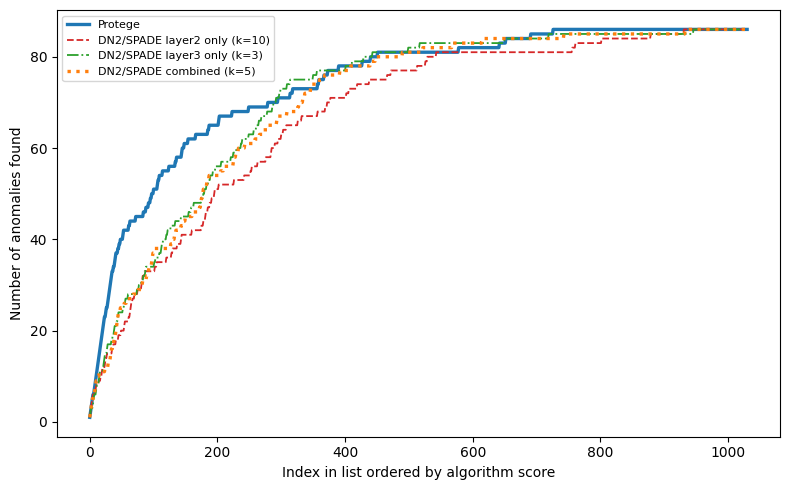

In [19]:
discovery_plot(
    ablation_methods,
    y_pc,
    highlight=['Protege', f'DN2/SPADE combined (k={best_k})']
)

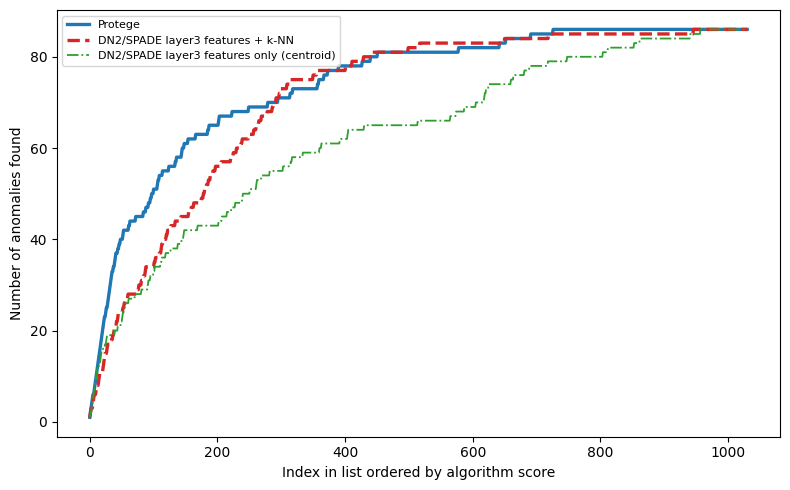

In [26]:
# ── 16.4  Discovery curves — one line per condition ─────────────────

discovery_plot(
    {
        'Protege':                                                    protege_scores_pc,
        f'DN2/SPADE {best_variant_repr} features + k-NN':              s_pc_knn,
    #    'B: BYOL feats + k-NN':                                       s_byol_knn,
        f'DN2/SPADE {best_variant_repr} features only (centroid)':     s_pc_centroid,
    #    'D: BYOL feats + centroid':                                   s_byol_centroid,
    },
    y_pc,
    highlight=['Protege', f'DN2/SPADE {best_variant_repr} features + k-NN'],
)